Ранее мы выяснили, что пользователи, совершившие покупку, реже быстро покидают сайт и в целом демонстрируют более высокую вовлеченность во взаимодействие с сайтом.

Теперь проверим, есть ли связь между более активным взаимодействием пользователя с административными и информационными страницами и снижением метрик ухода и повышением вероятности покупки. Для этого рассмотрим признаки Administrative, Administrative_Duration, Informational, Informational_Duration - на корреляционной матрице мы могли заметить достаточно высокие коэффициенты корреляции у этих признаков с ExitRates, BounceRates, а также Revenue.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.core.pylabtools import figsize

In [2]:
df = pd.read_csv('online_shoppers_intention.csv')

In [3]:
buyers = df[df['Revenue']==True]
not_buyers = df[df['Revenue']==False]

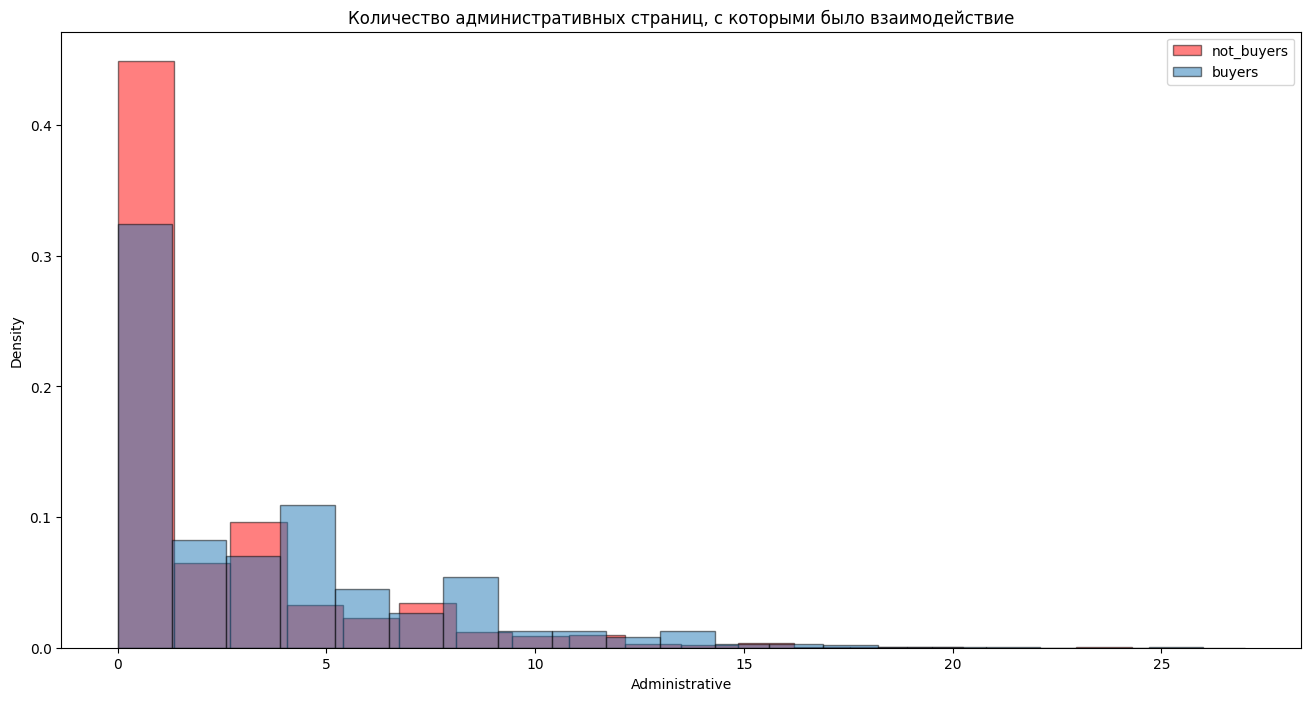

In [4]:
figsize(16, 8)

plt.hist(not_buyers['Administrative'], bins = 20, alpha=0.5, density=True, edgecolor = 'black', color='red', label='not_buyers')
plt.hist(buyers['Administrative'], bins = 20, alpha=0.5, density=True, edgecolor = 'black', label='buyers')

plt.xlabel('Administrative')
plt.ylabel('Density')
plt.title('Количество административных страниц, с которыми было взаимодействие')
plt.legend()

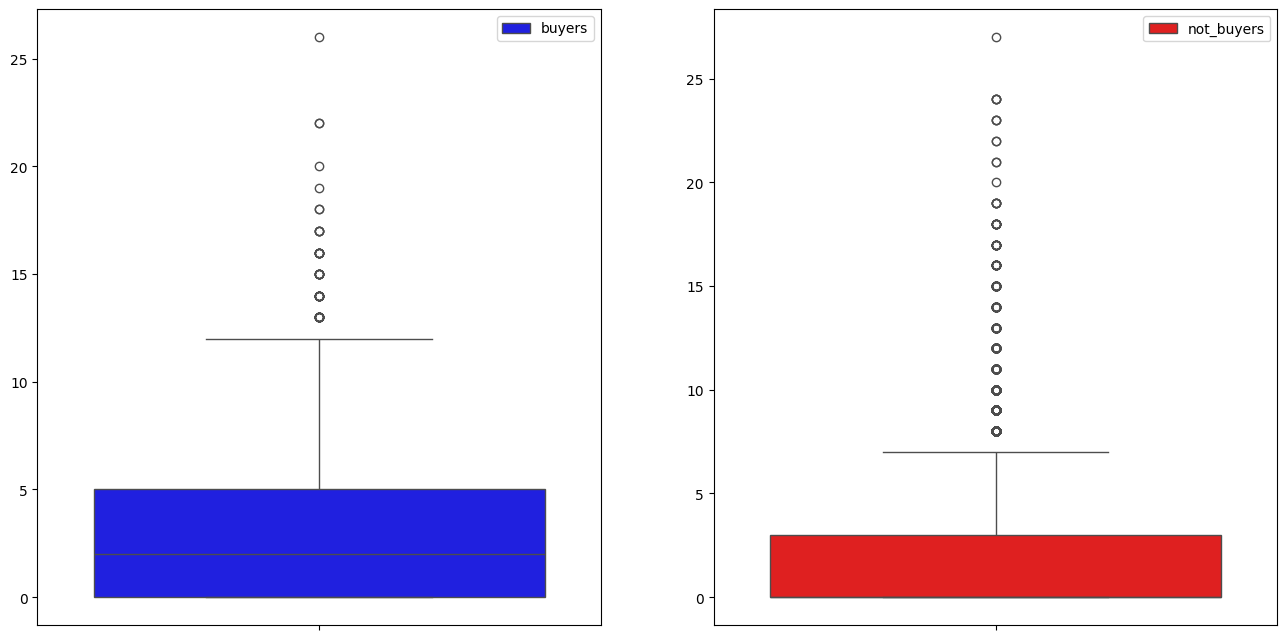

In [5]:
plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
sns.boxplot(data=buyers['Administrative'].values, color = 'blue', label='buyers')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(data=not_buyers['Administrative'].values, color = 'red', label='not_buyers')
plt.legend()

Из представленных графиков мы видим, что покупатели взаимодействуют с большим количеством административных страниц в течение сессии, чем не покупатели: у не покупателей большинство значений сосредоточено около 0, а также медиана у покупателей выше.

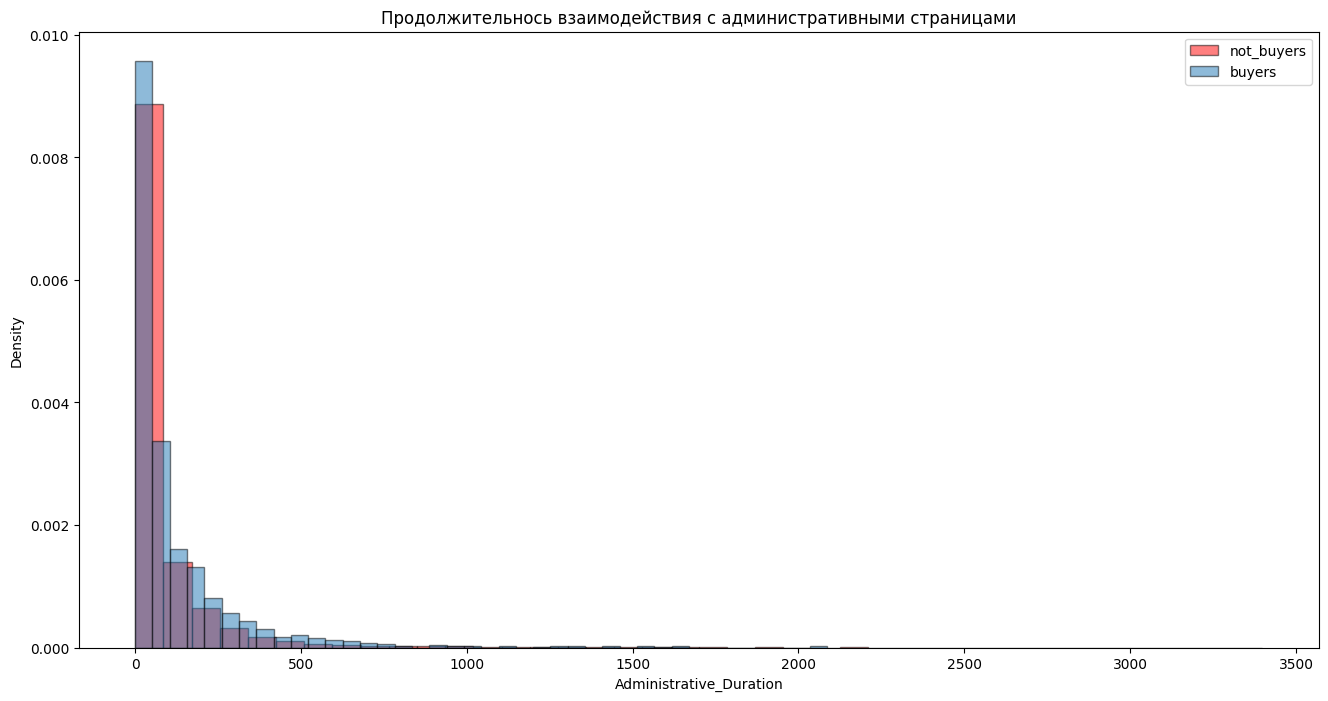

In [9]:
figsize(16, 8)

plt.hist(not_buyers['Administrative_Duration'], bins = 40, alpha=0.5, density=True, edgecolor = 'black', color='red', label='not_buyers')
plt.hist(buyers['Administrative_Duration'], bins = 40, alpha=0.5, density=True, edgecolor = 'black', label='buyers')

plt.xlabel('Administrative_Duration')
plt.ylabel('Density')
plt.title('Продолжительнось взаимодействия с административными страницами')
plt.legend()

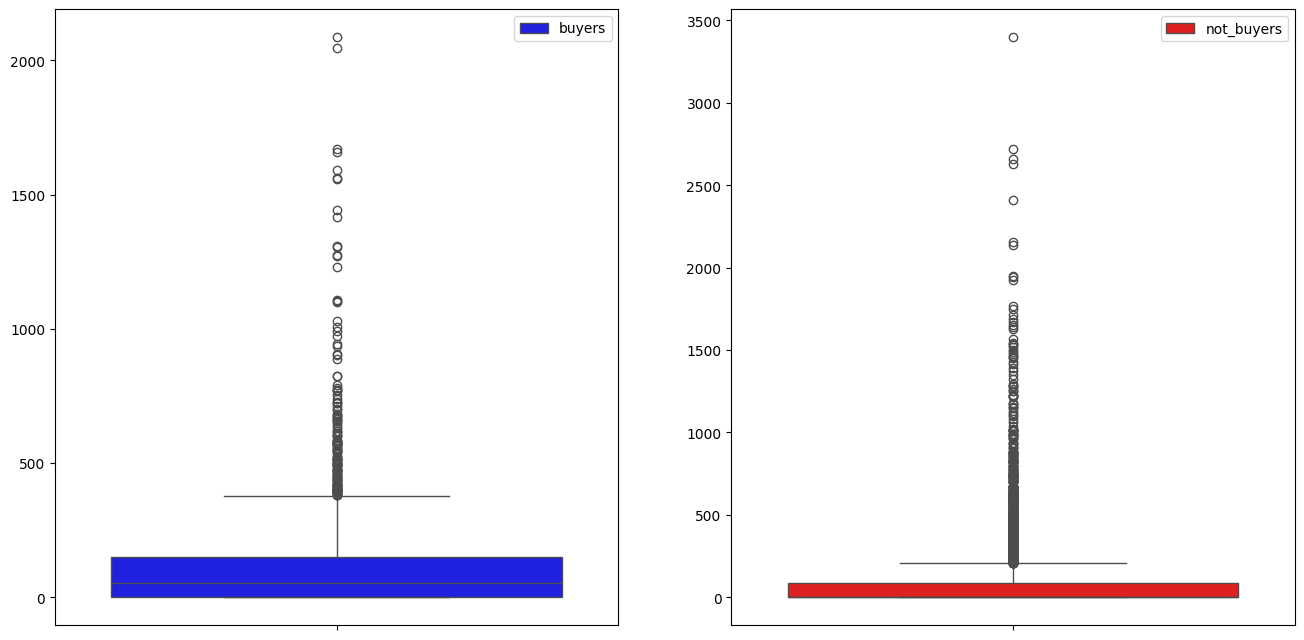

In [7]:
plt.figure(figsize=(16, 8))

plt.subplot(1,2,1)
sns.boxplot(data=buyers['Administrative_Duration'].values, color = 'blue', label='buyers')
plt.legend()

plt.subplot(1,2,2)
sns.boxplot(data=not_buyers['Administrative_Duration'].values, color = 'red', label='not_buyers')
plt.legend()

По графикам видно, что большое количество значений времени взаимодействия близко к 0 или 0. Также у не покупателей есть большие выбросы значений, что может свидетельствовать о том, что пользователь долго пытался разобраться с функционалом сайта, устал и не стал делать заказ.

Интересно было бы посмотреть на это в разрезе типовов покупателей (первый раз они на сайте или нет). Возможно, у пользователей, которые не 1 раз на сайте, взаимодействие с административными страницами отнимает меньше времени.

Уточним атрибуты функции boxplot https://seaborn.pydata.org/generated/seaborn.boxplot.html

<Axes: xlabel='VisitorType', ylabel='Administrative_Duration'>

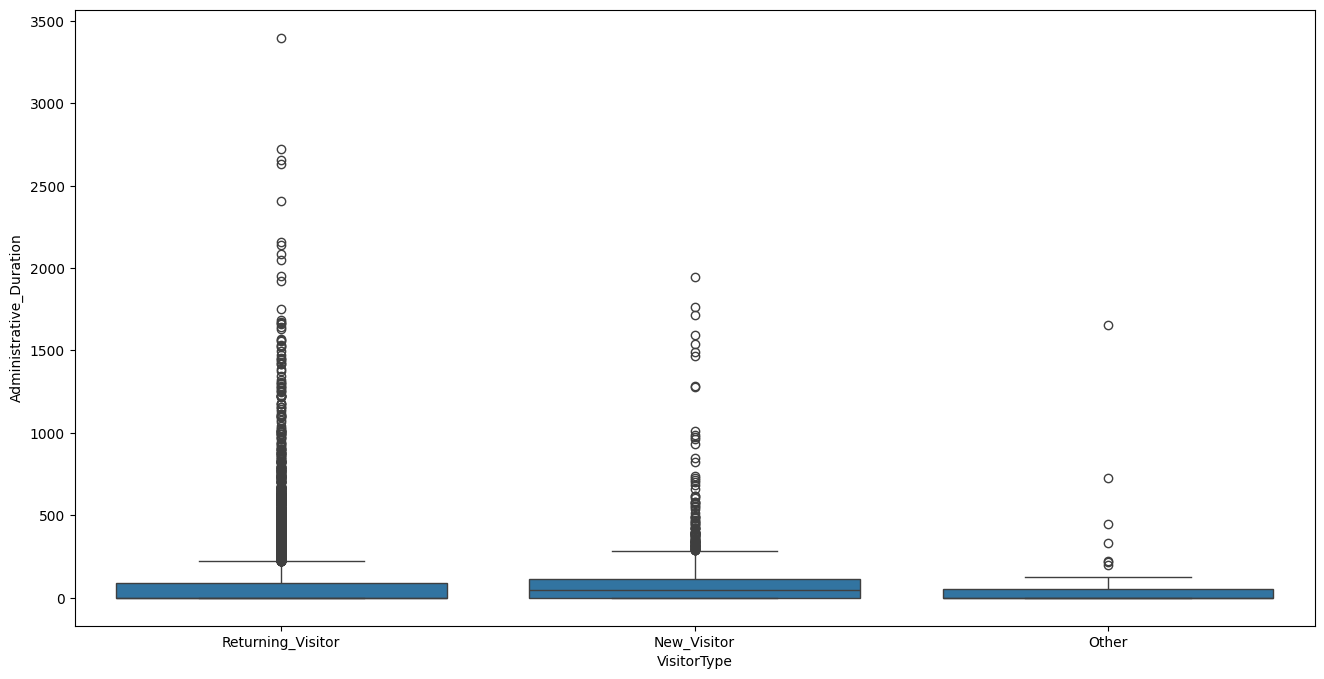

In [10]:
sns.boxplot(data=df, x='VisitorType', y='Administrative_Duration')

По графику видим, что в среднем новые пользователи дольше взимодействуют с административными страницами сайта, вероятно, изучают или регистрируются, при этом вернувшиеся пользователя иногда экстремально долго взаимодействует с данным типом страниц (о чем свидетелеьствуют выбросы). Причина у этого может быть разная, может, добавили в корзину/избранное и просматривают, а может, не могут разобраться в функционале и т.д.

<Axes: xlabel='VisitorType', ylabel='Administrative_Duration'>

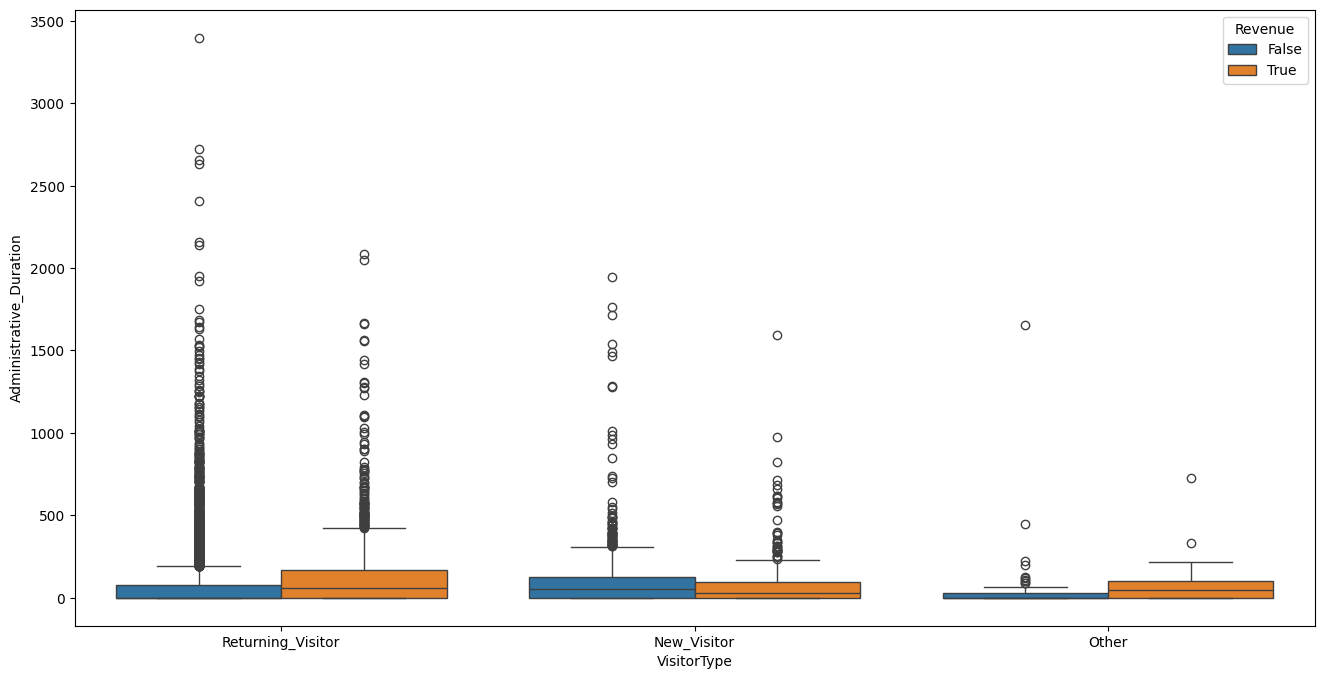

In [11]:
sns.boxplot(data=df, x='VisitorType', y='Administrative_Duration', hue='Revenue')

Итак, теперь мы видим, что вернувшиеся пользователи при дольшем взаимодействии с административными страницами чаще совершают покупку, вероятно, пользуются или для оформления заказа. При этом самые большие выбросы у группы вернувшихся пользователей, которые не сделали заказ. Это может говорить о нестандартном использовании страниц, например, просмотра корзины с добавленными продуктами, просмотра своего профиля и тд. 

У новых же посетителей долгое взаимодействие. административными страницами чаще приводит к отрицательному решению о покупке. Вероятно, непонятный функционал заставляет их уходить. Те же, кто быстро разобрался (их меньше), совершают покупку.

Далее интересно было бы посмотреть, как взаимодействие с разным типом страниц влияет на уход пользователя.

Например, посмотрим, есть ли зависимость между ExitRates и Administrative и выясним, влияет ли количество посещенных административных страниц на вероятность ухода пользователя.

Н0: Количество посещенных административных страниц не влияет на среднюю вероятность ухода с каждой страницы.

Н1: Количество посещенных административных страниц влияет на среднюю вероятность ухода с каждой страницы.

((array([-3.86207188, -3.63974939, -3.51782163, ...,  3.51782163,
          3.63974939,  3.86207188], shape=(12330,)),
  array([ 0,  0,  0, ..., 24, 26, 27], shape=(12330,))),
 (np.float64(2.8472976808009562),
  np.float64(2.315166261151662),
  np.float64(0.8569401200180667)))

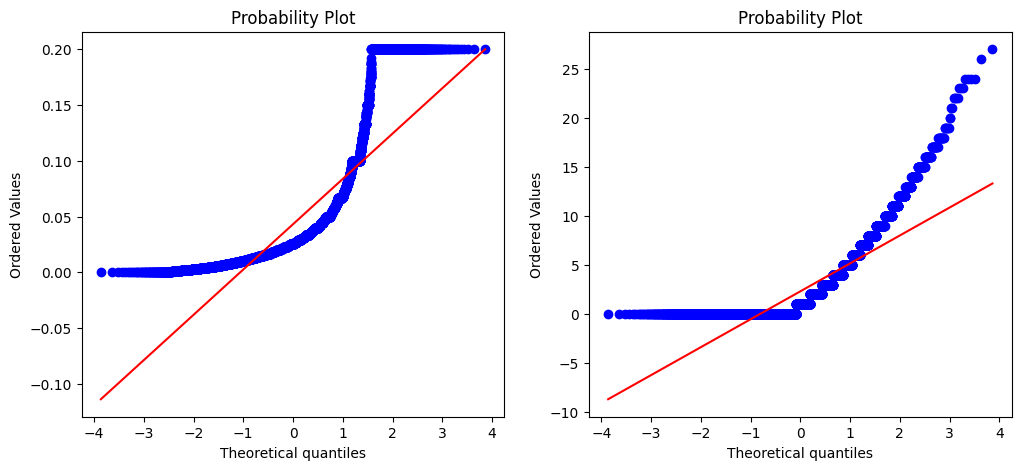

In [12]:
from scipy import stats
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
stats.probplot(df['ExitRates'], dist="norm", plot=plt)

plt.subplot(1, 2, 2)
stats.probplot(df['Administrative'], dist="norm", plot=plt)

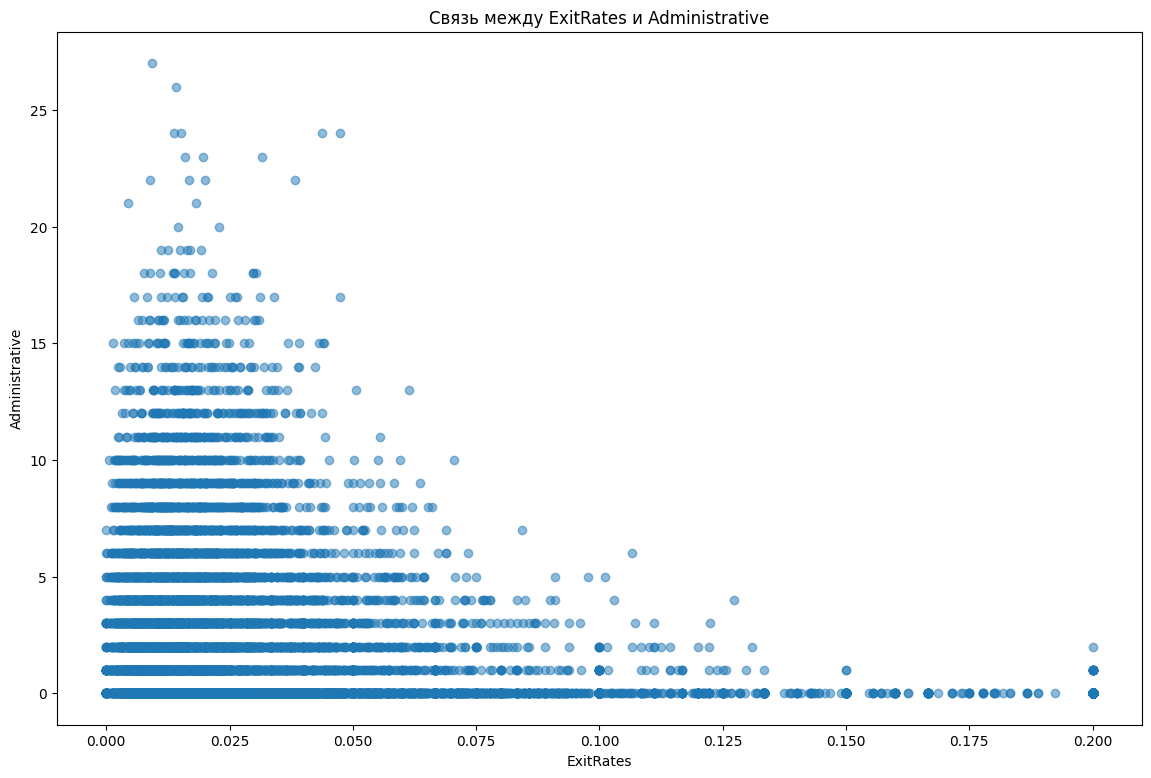

In [13]:
fig, ax = plt.subplots(figsize=(14,9))
color_graph = ax.scatter(df['ExitRates'],
                         df['Administrative'],
                         alpha=0.5)
ax.set_xlabel('ExitRates')
ax.set_ylabel('Administrative')

ax.set_title('Связь между ExitRates и Administrative')

plt.show()

In [14]:
from scipy.stats import spearmanr

spearmanr(df['Administrative'], df['ExitRates'])

SignificanceResult(statistic=np.float64(-0.4343889333418239), pvalue=np.float64(0.0))

Получился довольно интересный результат: между признаками есть умеренная отрицательная корреляция. То есть гипотезу H0 мы можем отклонить (т.к. p-value < 0.05) и сделать вывод, что количество посещенных административных страниц обратным образом слияет на агрегированную вероятность ухода с каждой страницы. То есть, можно предположить, что вероятность ухода с административных страниц низкая.